# Full-Time Goals Model (Model Group 2)

Predicts **expected full-time goals for each side** with count models, turns the
two means into a Dixon-Coles-adjusted score-probability grid, and derives every
goal market from that grid instead of training one classifier per betting line:

- Total goals over 0.5 / 1.5 / 2.5 / 3.5
- Team goals over (home 0.5/1.5, away 0.5/1.5)
- Goal ranges (0-1, 2-3, 4-5, 6+)
- G/G - both teams to score (BTTS)
- Scoreline-derived 1X2, compared read-only against the dedicated 1X2 classifier

Model ladder: constant league-mean baseline → Poisson GLM on core features →
**XGBoost `count:poisson` (primary)**, with the family chosen on validation
MAE + Poisson deviance. Direct XGBoost classifiers for Over 2.5 and BTTS are
trained as benchmarks only; the grid stays the product.

Shared pipeline (loading, Elo, leakage-safe rolling form, calibration, market
derivation) comes from the `src/football_prediction` package extracted from `1x2_pred.ipynb`.

## 1. Configuration

Split dates, rolling windows, and Elo settings come from `football_prediction.core.config` so
every model-group notebook scores the exact same train/validation/test windows.

In [1]:
import warnings

import joblib
import numpy
import pandas
import matplotlib.pyplot as pyplot
from IPython.display import display
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor

from src.football_prediction.core import config
from src.football_prediction.data import loading as data
from src.football_prediction.features import rolling as features
from src.football_prediction.features import state
from src.football_prediction.features.elo import add_elo_features
from src.football_prediction.modeling import calibration, metrics
from src.football_prediction.markets import goals as markets

warnings.filterwarnings("ignore", category=FutureWarning)

artifact_path = config.MODELS_DIRECTORY / "goals_pred.joblib"
match_1x2_artifact_path = config.MODELS_DIRECTORY / "match_1x2_pred.joblib"

random_seed = config.RANDOM_SEED
# 15 keeps the truncated tail below ~0.05% even for lopsided cup fixtures with
# expected goals around 5-6; the grid is renormalized either way.
max_goals = 15
minimum_expected_goals = 0.05
maximum_expected_goals = 8.0

# XGBoost count:poisson configuration, mirroring the 1x2 notebook's setup.
xgboost_parameters = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "early_stopping_rounds": 50,
    "n_jobs": -1,
    "random_state": random_seed,
}
max_depth_candidates = [3, 4, 5]
min_child_weight_candidates = [1, 5, 10]

# Raw columns beyond the shared base set. Big chances and shots inside the box
# only exist from the 2024-2025 season, so their form features ride the
# NaN-tolerant path exactly like xG does.
extra_raw_columns = [
    "home_big_chances_ft",
    "away_big_chances_ft",
    "home_shots_inside_box_ft",
    "away_shots_inside_box_ft",
]

# Team-perspective metrics for this model group.
own_metrics = {
    "goals_scored": "{side}_score_ft",
    "points": "{side}_points",
    "big_chances": "{side}_big_chances_ft",
    "shots_inside_box": "{side}_shots_inside_box_ft",
    "expected_goals_for": "{side}_expected_goals_ft",
}
opponent_metrics = {
    "goals_conceded": "{side}_score_ft",
    "big_chances_conceded": "{side}_big_chances_ft",
    "expected_goals_against": "{side}_expected_goals_ft",
}
short_rolling_metrics = ["goals_scored", "goals_conceded"]
long_rolling_metrics = ["goals_scored", "goals_conceded"]
nan_tolerant_rolling_metrics = [
    "big_chances",
    "big_chances_conceded",
    "shots_inside_box",
    "expected_goals_for",
    "expected_goals_against",
    "finishing_luck",
]
venue_rolling_metrics = ["goals_scored"]

core_feature_names = [
    "elo_difference",
    "home_elo",
    "away_elo",
    "home_goals_scored_form",
    "away_goals_scored_form",
    "home_goals_conceded_form",
    "away_goals_conceded_form",
    "home_long_goals_scored_form",
    "away_long_goals_scored_form",
    "home_long_goals_conceded_form",
    "away_long_goals_conceded_form",
    "home_attack_vs_away_defence",
    "away_attack_vs_home_defence",
    "home_goals_at_home_form",
    "away_goals_at_away_form",
    "rest_days_difference",
    "is_european_cup",
]
nan_tolerant_feature_names = [
    "home_big_chances_form",
    "away_big_chances_form",
    "home_big_chances_conceded_form",
    "away_big_chances_conceded_form",
    "home_shots_inside_box_form",
    "away_shots_inside_box_form",
    "home_xg_for_form",
    "away_xg_for_form",
    "home_xg_against_form",
    "away_xg_against_form",
    "home_finishing_luck_form",
    "away_finishing_luck_form",
]
feature_names = core_feature_names + nan_tolerant_feature_names

total_over_lines = [0.5, 1.5, 2.5, 3.5]
home_over_lines = [0.5, 1.5]
away_over_lines = [0.5, 1.5]
goal_range_bins = ((0, 1), (2, 3), (4, 5), (6, None))
goal_range_column_names = ["range_0_1", "range_2_3", "range_4_5", "range_6_plus"]

# Markets that get a Platt calibrator fitted on the validation window.
calibrated_market_names = [
    "over_1_5",
    "over_2_5",
    "over_3_5",
    "btts_yes",
    "home_over_1_5",
    "away_over_0_5",
]
# Markets the decision layer bets on (probability thresholds tuned on validation).
decision_market_names = ["over_1_5", "over_2_5", "over_3_5", "under_2_5", "btts_yes", "btts_no"]

pandas.set_option("display.max_columns", 80)
pandas.set_option("display.max_rows", 80)


## 2. Data loading and target base rates

`data.load_matches` applies the same required-column dropna and low-history team
filter as the 1X2 notebook, and derives `total_goals` for us. The extra big-chance
and shots-inside-box columns are only requested - never required.

In [2]:
matches, team_match_counts, team_filter_summary, load_summary = data.load_matches(
    extra_columns=extra_raw_columns,
)

print("Cleaned dataset shape and date range")
print("Rows and columns:", matches.shape)
print("Date range:", matches["date_utc"].min().date(), "to", matches["date_utc"].max().date())

print("\nData loading and filtering summary")
display(pandas.DataFrame([load_summary]))

print("\nGoal market base rates over the whole cleaned dataset")
base_rate_records = {
    "mean_home_goals": matches["home_score_ft"].mean(),
    "mean_away_goals": matches["away_score_ft"].mean(),
    "mean_total_goals": matches["total_goals"].mean(),
}
for line in total_over_lines:
    base_rate_records[f"over_{str(line).replace('.', '_')}_rate"] = (matches["total_goals"] > line).mean()
base_rate_records["btts_rate"] = ((matches["home_score_ft"] > 0) & (matches["away_score_ft"] > 0)).mean()
display(pandas.DataFrame([base_rate_records]).round(3))

print("\nExtra column coverage by season (big chances and shots inside box start in 2024-2025)")
display(
    matches.assign(
        has_big_chances=matches["home_big_chances_ft"].notna(),
        has_shots_inside_box=matches["home_shots_inside_box_ft"].notna(),
        has_expected_goals=matches["home_expected_goals_ft"].notna(),
    )
    .groupby("season")[["has_big_chances", "has_shots_inside_box", "has_expected_goals"]]
    .mean()
    .round(3)
)


Cleaned dataset shape and date range
Rows and columns: (14721, 40)
Date range: 2020-08-18 to 2026-05-30

Data loading and filtering summary


,rows_loaded,rows_after_required_columns,rows_after_team_filter,rows_removed_for_required_columns,rows_removed_for_low_history_teams,remaining_teams,minimum_remaining_team_matches
0,15645,15627,14721,18,906,322,10



Goal market base rates over the whole cleaned dataset


,mean_home_goals,mean_away_goals,mean_total_goals,over_0_5_rate,over_1_5_rate,over_2_5_rate,over_3_5_rate,btts_rate
0,1.559,1.259,2.817,0.936,0.77,0.533,0.312,0.535



Extra column coverage by season (big chances and shots inside box start in 2024-2025)


,has_big_chances,has_shots_inside_box,has_expected_goals
season,,,
2020-2021,0.000,0.000,0.000
2021-2022,0.000,0.000,0.000
2022-2023,0.000,0.000,0.378
2023-2024,0.000,0.000,0.907
2024-2025,0.603,0.603,0.898
2025-2026,0.932,0.932,0.932


## 3. Feature table

All rolling features exclude the current match (`closed="left"` inside
`features.add_rolling_team_form`), so every feature is knowable before kickoff.
Rows without a full short-window history are dropped on the core features only -
xG, big-chance, and shots-inside-box form stay NaN-tolerant for XGBoost.

In [3]:
def build_goals_feature_table(match_frame):
    matches_with_elo, final_team_ratings = add_elo_features(match_frame)
    team_match_rows = features.make_team_match_rows(
        matches_with_elo,
        own_metrics=own_metrics,
        opponent_metrics=opponent_metrics,
        ratio_metrics={},
    )
    rolling_team_form = features.add_rolling_team_form(
        team_match_rows,
        short_metrics=short_rolling_metrics,
        long_metrics=long_rolling_metrics,
        nan_tolerant_metrics=nan_tolerant_rolling_metrics,
        venue_metrics=venue_rolling_metrics,
    )
    form_columns = features.form_column_names(
        short_rolling_metrics,
        long_rolling_metrics,
        nan_tolerant_rolling_metrics,
        venue_rolling_metrics,
    )
    feature_table = features.merge_side_form(matches_with_elo, rolling_team_form, form_columns)

    # Scoring and conceding form.
    feature_table["home_goals_scored_form"] = feature_table["home_rolling_goals_scored"]
    feature_table["away_goals_scored_form"] = feature_table["away_rolling_goals_scored"]
    feature_table["home_goals_conceded_form"] = feature_table["home_rolling_goals_conceded"]
    feature_table["away_goals_conceded_form"] = feature_table["away_rolling_goals_conceded"]
    feature_table["home_long_goals_scored_form"] = feature_table["home_long_rolling_goals_scored"]
    feature_table["away_long_goals_scored_form"] = feature_table["away_long_rolling_goals_scored"]
    feature_table["home_long_goals_conceded_form"] = feature_table["home_long_rolling_goals_conceded"]
    feature_table["away_long_goals_conceded_form"] = feature_table["away_long_rolling_goals_conceded"]

    # Cross-matched attack vs defence and venue-specific scoring.
    feature_table["home_attack_vs_away_defence"] = (
        feature_table["home_rolling_goals_scored"] - feature_table["away_rolling_goals_conceded"]
    )
    feature_table["away_attack_vs_home_defence"] = (
        feature_table["away_rolling_goals_scored"] - feature_table["home_rolling_goals_conceded"]
    )
    feature_table["home_goals_at_home_form"] = feature_table["home_rolling_goals_scored_at_venue"]
    feature_table["away_goals_at_away_form"] = feature_table["away_rolling_goals_scored_at_venue"]
    feature_table["rest_days_difference"] = (
        feature_table["home_rest_days"] - feature_table["away_rest_days"]
    )

    # NaN-tolerant chance-creation and xG form.
    feature_table["home_big_chances_form"] = feature_table["home_rolling_big_chances"]
    feature_table["away_big_chances_form"] = feature_table["away_rolling_big_chances"]
    feature_table["home_big_chances_conceded_form"] = feature_table["home_rolling_big_chances_conceded"]
    feature_table["away_big_chances_conceded_form"] = feature_table["away_rolling_big_chances_conceded"]
    feature_table["home_shots_inside_box_form"] = feature_table["home_rolling_shots_inside_box"]
    feature_table["away_shots_inside_box_form"] = feature_table["away_rolling_shots_inside_box"]
    feature_table["home_xg_for_form"] = feature_table["home_rolling_expected_goals_for"]
    feature_table["away_xg_for_form"] = feature_table["away_rolling_expected_goals_for"]
    feature_table["home_xg_against_form"] = feature_table["home_rolling_expected_goals_against"]
    feature_table["away_xg_against_form"] = feature_table["away_rolling_expected_goals_against"]
    feature_table["home_finishing_luck_form"] = feature_table["home_rolling_finishing_luck"]
    feature_table["away_finishing_luck_form"] = feature_table["away_rolling_finishing_luck"]

    return feature_table, team_match_rows, rolling_team_form, final_team_ratings


feature_table, team_match_rows, rolling_team_form, final_team_ratings = build_goals_feature_table(matches)
model_data = feature_table.dropna(subset=core_feature_names).copy()

# Leakage spot-check: a rolling value must equal the mean of the previous
# short-window matches, never including the current one.
example_team = rolling_team_form["team"].iloc[0]
example_history = rolling_team_form[rolling_team_form["team"].eq(example_team)].sort_values(
    ["date_utc", "match_id"]
)
check_position = 10
manual_mean = example_history["goals_scored"].iloc[check_position - 5:check_position].mean()
assert abs(example_history["rolling_goals_scored"].iloc[check_position] - manual_mean) < 1e-12
print(f"Leakage spot-check passed: rolling_goals_scored for {example_team} at match "
      f"{check_position} equals the mean of its previous 5 matches ({manual_mean:.3f})")

print("\nFeature build summary")
display(pandas.DataFrame([{
    "rows_before_dropping_no_history_rows": len(feature_table),
    "rows_after_dropping_no_history_rows": len(model_data),
    "rows_dropped": len(feature_table) - len(model_data),
    "core_features": len(core_feature_names),
    "missing_tolerant_features": len(nan_tolerant_feature_names),
    "total_features": len(feature_names),
}]))

print("\nMissing-tolerant feature availability (share of modelled rows with a value)")
display(
    model_data[nan_tolerant_feature_names].notna().mean().rename("available").round(3).to_frame()
)


Leakage spot-check passed: rolling_goals_scored for linfield at match 10 equals the mean of its previous 5 matches (0.400)

Feature build summary


,rows_before_dropping_no_history_rows,rows_after_dropping_no_history_rows,rows_dropped,core_features,missing_tolerant_features,total_features
0,14721,12475,2246,17,12,29



Missing-tolerant feature availability (share of modelled rows with a value)


,available
home_big_chances_form,0.282
away_big_chances_form,0.284
home_big_chances_conceded_form,0.282
away_big_chances_conceded_form,0.284
home_shots_inside_box_form,0.282
away_shots_inside_box_form,0.284
home_xg_for_form,0.581
away_xg_for_form,0.582
home_xg_against_form,0.581
away_xg_against_form,0.582


## 4. Temporal split

Identical dates to the 1X2 notebook (`football_prediction.core.config`): train before 2025-07-01,
validate to 2026-01-01, test after - so the grid-derived 1X2 comparison later is
apples-to-apples.

In [4]:
training_matches = model_data[model_data["date_utc"] < config.VALIDATION_SPLIT_DATE].copy()
validation_matches = model_data[
    (model_data["date_utc"] >= config.VALIDATION_SPLIT_DATE)
    & (model_data["date_utc"] < config.TEST_SPLIT_DATE)
].copy()
test_matches = model_data[model_data["date_utc"] >= config.TEST_SPLIT_DATE].copy()

split_summary = pandas.DataFrame([
    {
        "split": split_name,
        "rows": len(split_frame),
        "start": split_frame["date_utc"].min().date(),
        "end": split_frame["date_utc"].max().date(),
        "mean_home_goals": split_frame["home_score_ft"].mean(),
        "mean_away_goals": split_frame["away_score_ft"].mean(),
        "over_2_5_rate": (split_frame["total_goals"] > 2.5).mean(),
        "btts_rate": ((split_frame["home_score_ft"] > 0) & (split_frame["away_score_ft"] > 0)).mean(),
    }
    for split_name, split_frame in [
        ("training", training_matches),
        ("validation", validation_matches),
        ("test", test_matches),
    ]
])
print("Temporal three-way split summary")
print(f"Validation from {config.VALIDATION_SPLIT_DATE.date()}, test from {config.TEST_SPLIT_DATE.date()}")
display(split_summary.round(3))

training_feature_matrix = training_matches[feature_names]
validation_feature_matrix = validation_matches[feature_names]
test_feature_matrix = test_matches[feature_names]


Temporal three-way split summary
Validation from 2025-07-01, test from 2026-01-01


,split,rows,start,end,mean_home_goals,mean_away_goals,over_2_5_rate,btts_rate
0,training,10072,2020-11-05,2025-05-31,1.553,1.272,0.534,0.544
1,validation,1251,2025-07-08,2025-12-30,1.568,1.183,0.526,0.503
2,test,1152,2026-01-01,2026-05-30,1.575,1.266,0.546,0.556


## 5. Baselines

Two count baselines per side: a constant league-mean Poisson, and a Poisson GLM
(with scaling) on the core features only - GLMs cannot take the NaN-tolerant
columns.

In [5]:
constant_home_mu = float(training_matches["home_score_ft"].mean())
constant_away_mu = float(training_matches["away_score_ft"].mean())
print(f"Constant baseline expected goals: home {constant_home_mu:.3f}, away {constant_away_mu:.3f}")

poisson_glm_models = {}
for side_name, target_column in [("home", "home_score_ft"), ("away", "away_score_ft")]:
    glm_pipeline = make_pipeline(
        StandardScaler(),
        PoissonRegressor(alpha=1e-4, max_iter=500),
    )
    glm_pipeline.fit(training_matches[core_feature_names], training_matches[target_column])
    poisson_glm_models[side_name] = glm_pipeline

baseline_validation_records = []
for side_name, target_column in [("home", "home_score_ft"), ("away", "away_score_ft")]:
    constant_mu = constant_home_mu if side_name == "home" else constant_away_mu
    baseline_validation_records.append({
        "model": "constant_league_mean",
        "side": side_name,
        **metrics.count_metrics(
            validation_matches[target_column],
            numpy.full(len(validation_matches), constant_mu),
        ),
    })
    baseline_validation_records.append({
        "model": "poisson_glm_core_features",
        "side": side_name,
        **metrics.count_metrics(
            validation_matches[target_column],
            poisson_glm_models[side_name].predict(validation_matches[core_feature_names]),
        ),
    })

print("\nCount baselines on the validation window")
display(pandas.DataFrame(baseline_validation_records).round(4))


Constant baseline expected goals: home 1.553, away 1.272

Count baselines on the validation window


,model,side,mae,rmse,poisson_deviance
0,constant_league_mean,home,1.0886,1.3319,1.2980
1,poisson_glm_core_features,home,1.0056,1.2519,1.1727
2,constant_league_mean,away,0.9461,1.1885,1.3027
3,poisson_glm_core_features,away,0.8824,1.1284,1.1923


## 6. XGBoost count models and family selection

One `count:poisson` regressor per side, early-stopped on validation Poisson
negative log-likelihood, with the same depth × min-child-weight sweep pattern as
the 1X2 notebook (the sweep score is the average validation Poisson deviance of
the home and away models). The final family is whichever rung of the ladder wins
on validation deviance.

In [6]:
def fit_count_model(target_column, max_depth_value, min_child_weight_value):
    count_model = XGBRegressor(
        **xgboost_parameters,
        objective="count:poisson",
        eval_metric="poisson-nloglik",
        max_depth=max_depth_value,
        min_child_weight=min_child_weight_value,
    )
    count_model.fit(
        training_feature_matrix,
        training_matches[target_column],
        eval_set=[(validation_feature_matrix, validation_matches[target_column])],
        verbose=False,
    )
    return count_model


sweep_records = []
best_sweep_record = None
best_sweep_models = None

for max_depth_value in max_depth_candidates:
    for min_child_weight_value in min_child_weight_candidates:
        candidate_models = {
            "home": fit_count_model("home_score_ft", max_depth_value, min_child_weight_value),
            "away": fit_count_model("away_score_ft", max_depth_value, min_child_weight_value),
        }
        side_deviances = {}
        for side_name, target_column in [("home", "home_score_ft"), ("away", "away_score_ft")]:
            predicted_mu = numpy.clip(
                candidate_models[side_name].predict(validation_feature_matrix),
                minimum_expected_goals,
                maximum_expected_goals,
            )
            side_deviances[side_name] = metrics.count_metrics(
                validation_matches[target_column], predicted_mu
            )["poisson_deviance"]
        sweep_record = {
            "max_depth": max_depth_value,
            "min_child_weight": min_child_weight_value,
            "home_best_iteration": int(candidate_models["home"].best_iteration),
            "away_best_iteration": int(candidate_models["away"].best_iteration),
            "home_poisson_deviance": side_deviances["home"],
            "away_poisson_deviance": side_deviances["away"],
            "mean_poisson_deviance": (side_deviances["home"] + side_deviances["away"]) / 2.0,
        }
        sweep_records.append(sweep_record)
        if (
            best_sweep_record is None
            or sweep_record["mean_poisson_deviance"] < best_sweep_record["mean_poisson_deviance"]
        ):
            best_sweep_record = sweep_record
            best_sweep_models = candidate_models

sweep_table = pandas.DataFrame(sweep_records).sort_values("mean_poisson_deviance").reset_index(drop=True)
print("Validation sweep (sorted by mean validation Poisson deviance)")
display(sweep_table.round(4))

best_max_depth = best_sweep_record["max_depth"]
best_min_child_weight = best_sweep_record["min_child_weight"]
xgboost_goal_models = best_sweep_models
print(f"\nSelected configuration: max_depth={best_max_depth}, min_child_weight={best_min_child_weight}")


def expected_goals_for_family(family_name, split_frame):
    if family_name == "constant_league_mean":
        home_mu = numpy.full(len(split_frame), constant_home_mu)
        away_mu = numpy.full(len(split_frame), constant_away_mu)
    elif family_name == "poisson_glm":
        home_mu = poisson_glm_models["home"].predict(split_frame[core_feature_names])
        away_mu = poisson_glm_models["away"].predict(split_frame[core_feature_names])
    elif family_name == "xgboost_count_poisson":
        home_mu = xgboost_goal_models["home"].predict(split_frame[feature_names])
        away_mu = xgboost_goal_models["away"].predict(split_frame[feature_names])
    else:
        raise ValueError(f"Unknown model family {family_name!r}")
    return (
        numpy.clip(home_mu, minimum_expected_goals, maximum_expected_goals),
        numpy.clip(away_mu, minimum_expected_goals, maximum_expected_goals),
    )


family_records = []
for family_name in ["constant_league_mean", "poisson_glm", "xgboost_count_poisson"]:
    validation_home_mu, validation_away_mu = expected_goals_for_family(family_name, validation_matches)
    home_metrics = metrics.count_metrics(validation_matches["home_score_ft"], validation_home_mu)
    away_metrics = metrics.count_metrics(validation_matches["away_score_ft"], validation_away_mu)
    family_records.append({
        "family": family_name,
        "home_mae": home_metrics["mae"],
        "away_mae": away_metrics["mae"],
        "home_poisson_deviance": home_metrics["poisson_deviance"],
        "away_poisson_deviance": away_metrics["poisson_deviance"],
        "mean_poisson_deviance": (home_metrics["poisson_deviance"] + away_metrics["poisson_deviance"]) / 2.0,
    })

family_table = pandas.DataFrame(family_records).sort_values("mean_poisson_deviance").reset_index(drop=True)
print("\nModel family comparison on the validation window")
display(family_table.round(4))

selected_model_family = family_table.iloc[0]["family"]
print(f"\nSelected model family: {selected_model_family}")


def predict_expected_goals(split_frame):
    return expected_goals_for_family(selected_model_family, split_frame)


Validation sweep (sorted by mean validation Poisson deviance)


,max_depth,min_child_weight,home_best_iteration,away_best_iteration,home_poisson_deviance,away_poisson_deviance,mean_poisson_deviance
0,3,10,134,78,1.1685,1.2013,1.1849
1,3,5,130,78,1.1688,1.2017,1.1853
2,3,1,130,78,1.1689,1.2022,1.1856
3,5,10,133,72,1.1649,1.2068,1.1858
4,4,10,133,70,1.1667,1.2065,1.1866
5,4,5,133,71,1.1666,1.2067,1.1866
6,5,1,134,167,1.1683,1.2052,1.1868
7,4,1,133,70,1.1670,1.2070,1.1870
8,5,5,139,72,1.1672,1.2076,1.1874



Selected configuration: max_depth=3, min_child_weight=10

Model family comparison on the validation window


,family,home_mae,away_mae,home_poisson_deviance,away_poisson_deviance,mean_poisson_deviance
0,poisson_glm,1.0056,0.8824,1.1727,1.1923,1.1825
1,xgboost_count_poisson,0.9954,0.8871,1.1685,1.2013,1.1849
2,constant_league_mean,1.0886,0.9461,1.2980,1.3027,1.3003



Selected model family: poisson_glm


## 7. Dixon-Coles adjustment and score grids

Independent Poissons misprice the low-scoring corner of the grid (0-0, 1-0, 0-1,
1-1). The Dixon-Coles rho is fitted once on the training window by profile
likelihood, on top of the selected mean model, then applied to every grid.

In [7]:
training_home_mu, training_away_mu = predict_expected_goals(training_matches)
dixon_coles_rho = markets.fit_dixon_coles_rho(
    training_matches["home_score_ft"].to_numpy(),
    training_matches["away_score_ft"].to_numpy(),
    training_home_mu,
    training_away_mu,
)
print(f"Fitted Dixon-Coles rho on the training window: {dixon_coles_rho:.4f}")


def build_split_grid(split_frame):
    home_mu, away_mu = predict_expected_goals(split_frame)
    grid, pre_normalization_mass = markets.build_score_grid(
        home_mu, away_mu, max_goals=max_goals, rho=dixon_coles_rho,
    )
    return grid, pre_normalization_mass


training_grid, training_mass = build_split_grid(training_matches)
validation_grid, validation_mass = build_split_grid(validation_matches)
test_grid, test_mass = build_split_grid(test_matches)

for split_name, grid, mass in [
    ("training", training_grid, training_mass),
    ("validation", validation_grid, validation_mass),
    ("test", test_grid, test_mass),
]:
    assert numpy.allclose(grid.sum(axis=(1, 2)), 1.0), f"{split_name} grid rows do not sum to 1"
    assert mass.min() >= 0.995, f"{split_name} pre-normalization mass too low: {mass.min():.6f}"
    low_mass_share = float((mass < 0.999).mean())
    print(f"{split_name}: grids sum to 1, minimum pre-normalization mass {mass.min():.6f}, "
          f"share of matches below 0.999 mass: {low_mass_share:.4f}")


def line_column(prefix, line):
    return f"{prefix}_{str(line).replace('.', '_')}"


def derive_goal_markets(grid):
    market_frame = pandas.DataFrame()
    for line in total_over_lines:
        market_frame[line_column("over", line)] = markets.grid_total_over(grid, line)
    for line in home_over_lines:
        market_frame[line_column("home_over", line)] = markets.grid_team_over(grid, "home", line)
    for line in away_over_lines:
        market_frame[line_column("away_over", line)] = markets.grid_team_over(grid, "away", line)
    market_frame["btts_yes"] = markets.grid_btts(grid)
    for range_label, range_probability in markets.grid_goal_ranges(grid, goal_range_bins).items():
        range_column = "range_" + range_label.replace("-", "_").replace("+", "_plus")
        market_frame[range_column] = range_probability
    grid_one_x_two = markets.grid_1x2(grid)
    market_frame["home_win_probability"] = grid_one_x_two[:, 0]
    market_frame["draw_probability"] = grid_one_x_two[:, 1]
    market_frame["away_win_probability"] = grid_one_x_two[:, 2]
    return market_frame


def market_outcome(match_frame, market_name):
    if market_name.startswith("home_over_"):
        line = float(market_name[len("home_over_"):].replace("_", "."))
        return (match_frame["home_score_ft"] > line).astype(int)
    if market_name.startswith("away_over_"):
        line = float(market_name[len("away_over_"):].replace("_", "."))
        return (match_frame["away_score_ft"] > line).astype(int)
    if market_name.startswith("over_"):
        line = float(market_name[len("over_"):].replace("_", "."))
        return (match_frame["total_goals"] > line).astype(int)
    if market_name.startswith("under_"):
        line = float(market_name[len("under_"):].replace("_", "."))
        return (match_frame["total_goals"] < line).astype(int)
    if market_name == "btts_yes":
        return ((match_frame["home_score_ft"] > 0) & (match_frame["away_score_ft"] > 0)).astype(int)
    if market_name == "btts_no":
        return 1 - ((match_frame["home_score_ft"] > 0) & (match_frame["away_score_ft"] > 0)).astype(int)
    raise ValueError(f"Unknown market {market_name!r}")


training_market_frame = derive_goal_markets(training_grid)
validation_market_frame = derive_goal_markets(validation_grid)
test_market_frame = derive_goal_markets(test_grid)

# Sanity: on the training window the mean derived probability must sit close to
# the empirical rate for the headline markets.
sanity_records = []
for market_name in ["over_2_5", "btts_yes"]:
    mean_predicted = float(training_market_frame[market_name].mean())
    empirical_rate = float(market_outcome(training_matches, market_name).mean())
    sanity_records.append({
        "market": market_name,
        "mean_predicted_train": mean_predicted,
        "empirical_rate_train": empirical_rate,
        "gap": mean_predicted - empirical_rate,
    })
    assert abs(mean_predicted - empirical_rate) < 0.05, f"{market_name} calibration drift too large"
print("\nTraining-window sanity check: mean derived probability vs empirical rate")
display(pandas.DataFrame(sanity_records).round(4))

example_row = 0
example_scorelines = markets.grid_exact_scores(validation_grid[example_row:example_row + 1], top_k=5)[0]
example_match = validation_matches.iloc[example_row]
print(f"\nMost likely scorelines for {example_match['home_team']} vs {example_match['away_team']} "
      f"({example_match['date_utc'].date()}):")
for scoreline, probability in example_scorelines:
    print(f"  {scoreline}: {probability:.3f}")


Fitted Dixon-Coles rho on the training window: -0.0314
training: grids sum to 1, minimum pre-normalization mass 0.999948, share of matches below 0.999 mass: 0.0000
validation: grids sum to 1, minimum pre-normalization mass 0.999996, share of matches below 0.999 mass: 0.0000
test: grids sum to 1, minimum pre-normalization mass 0.999903, share of matches below 0.999 mass: 0.0000

Training-window sanity check: mean derived probability vs empirical rate


,market,mean_predicted_train,empirical_rate_train,gap
0,over_2_5,0.5333,0.5345,-0.0012
1,btts_yes,0.5343,0.5440,-0.0097



Most likely scorelines for kups vs milsami (2025-07-08):
  1-1: 0.120
  1-0: 0.106
  2-1: 0.096
  2-0: 0.090
  0-0: 0.070


## 8. Market calibration

Platt calibrators are fitted on the validation window for the headline markets
(raw grid probabilities tend to be slightly overconfident because real goals are
a touch overdispersed vs Poisson). Reliability curves show before/after.

Validation market metrics before and after calibration (in-sample for the calibrators)


,market,rows,log_loss,brier,mean_predicted,empirical_rate
0,over_1_5 (raw),1251,0.5672,0.1905,0.7760,0.7394
1,over_2_5 (raw),1251,0.6805,0.2439,0.5395,0.5260
2,over_3_5 (raw),1251,0.6076,0.2089,0.3202,0.3038
3,btts_yes (raw),1251,0.6936,0.2502,0.5368,0.5028
4,home_over_1_5 (raw),1251,0.6455,0.2272,0.4543,0.4596
5,away_over_0_5 (raw),1251,0.6098,0.2113,0.7007,0.6691
6,over_1_5 (calibrated),1251,0.5633,0.1890,0.7394,0.7394
7,over_2_5 (calibrated),1251,0.6801,0.2437,0.5259,0.5260
8,over_3_5 (calibrated),1251,0.6066,0.2083,0.3038,0.3038
9,btts_yes (calibrated),1251,0.6911,0.2490,0.5028,0.5028


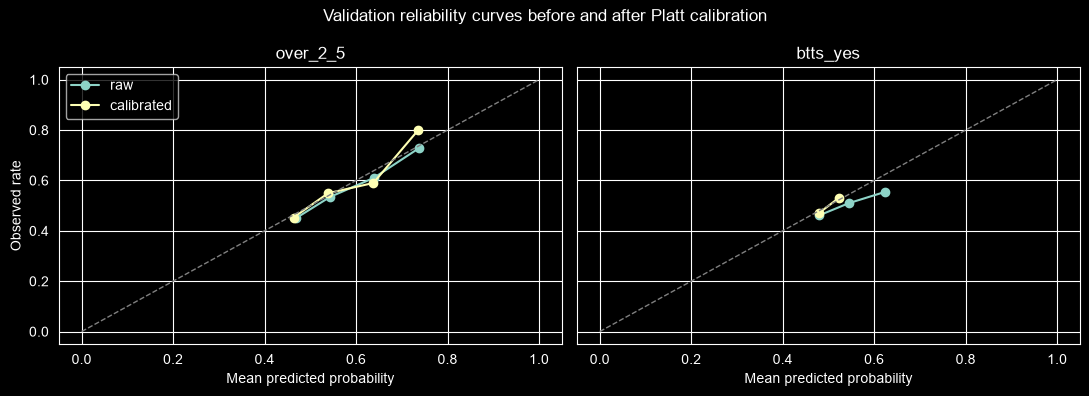

In [8]:
market_calibrators = {}
for market_name in calibrated_market_names:
    market_calibrators[market_name] = calibration.fit_binary_platt(
        validation_market_frame[market_name].to_numpy(),
        market_outcome(validation_matches, market_name).to_numpy(),
    )


def apply_market_calibration(market_frame):
    calibrated_frame = market_frame.copy()
    for market_name, market_calibrator in market_calibrators.items():
        calibrated_frame[market_name] = calibration.apply_binary_calibration(
            market_frame[market_name].to_numpy(), market_calibrator,
        )
    return calibrated_frame


validation_calibrated_market_frame = apply_market_calibration(validation_market_frame)

validation_market_eval = metrics.market_eval_table({
    **{
        f"{market_name} (raw)": (
            validation_market_frame[market_name].to_numpy(),
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
    **{
        f"{market_name} (calibrated)": (
            validation_calibrated_market_frame[market_name].to_numpy(),
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
})
print("Validation market metrics before and after calibration "
      "(in-sample for the calibrators)")
display(validation_market_eval.round(4))

figure, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for market_name, axis in zip(["over_2_5", "btts_yes"], axes):
    outcome_indicator = market_outcome(validation_matches, market_name).to_numpy().astype(float)
    for curve_label, probability_values in [
        ("raw", validation_market_frame[market_name].to_numpy()),
        ("calibrated", validation_calibrated_market_frame[market_name].to_numpy()),
    ]:
        curve_table = calibration.reliability_table(probability_values, outcome_indicator)
        axis.plot(curve_table["mean_predicted"], curve_table["observed_rate"], marker="o", label=curve_label)
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axis.set_title(market_name)
    axis.set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed rate")
axes[0].legend()
figure.suptitle("Validation reliability curves before and after Platt calibration")
pyplot.tight_layout()
pyplot.show()


## 9. Benchmark: direct binary classifiers

Per the modelling notes, per-line classifiers are the comparison, not the
product. One XGBoost classifier each for Over 2.5 and BTTS on the same features.

In [9]:
benchmark_market_names = ["over_2_5", "btts_yes"]
benchmark_classifiers = {}
for market_name in benchmark_market_names:
    benchmark_classifier = XGBClassifier(
        **xgboost_parameters,
        eval_metric="logloss",
        max_depth=best_max_depth,
        min_child_weight=best_min_child_weight,
    )
    benchmark_classifier.fit(
        training_feature_matrix,
        market_outcome(training_matches, market_name),
        eval_set=[(validation_feature_matrix, market_outcome(validation_matches, market_name))],
        verbose=False,
    )
    benchmark_classifiers[market_name] = benchmark_classifier

benchmark_validation_eval = metrics.market_eval_table({
    **{
        f"{market_name} grid raw": (
            validation_market_frame[market_name].to_numpy(),
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in benchmark_market_names
    },
    **{
        f"{market_name} grid calibrated": (
            validation_calibrated_market_frame[market_name].to_numpy(),
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in benchmark_market_names
    },
    **{
        f"{market_name} direct classifier": (
            benchmark_classifiers[market_name].predict_proba(validation_feature_matrix)[:, 1],
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in benchmark_market_names
    },
})
print("Grid-derived vs direct classifier on the validation window")
display(benchmark_validation_eval.sort_values("market").round(4))


Grid-derived vs direct classifier on the validation window


,market,rows,log_loss,brier,mean_predicted,empirical_rate
5,btts_yes direct classifier,1251,0.6965,0.2517,0.5479,0.5028
3,btts_yes grid calibrated,1251,0.6911,0.2490,0.5028,0.5028
1,btts_yes grid raw,1251,0.6936,0.2502,0.5368,0.5028
4,over_2_5 direct classifier,1251,0.6854,0.2462,0.5418,0.5260
2,over_2_5 grid calibrated,1251,0.6801,0.2437,0.5259,0.5260
0,over_2_5 grid raw,1251,0.6805,0.2439,0.5395,0.5260


## 10. Grid-derived 1X2 vs the dedicated classifier

The score grid yields 1X2 probabilities for free. They are compared read-only
against the calibrated probabilities the 1X2 notebook stored in its artifact
(matched on date and team names over the shared test matches).

In [10]:
from sklearn.metrics import log_loss as sklearn_log_loss

if match_1x2_artifact_path.exists():
    match_1x2_artifact = joblib.load(match_1x2_artifact_path)
    stored_1x2_test = match_1x2_artifact["test_evaluation_table"][[
        "date_utc", "home_team", "away_team", "match_result",
        "home_win_probability", "draw_probability", "away_win_probability",
    ]].copy()

    grid_1x2_test = test_matches[["date_utc", "home_team", "away_team"]].reset_index(drop=True).copy()
    grid_1x2_test["grid_home_win_probability"] = test_market_frame["home_win_probability"].to_numpy()
    grid_1x2_test["grid_draw_probability"] = test_market_frame["draw_probability"].to_numpy()
    grid_1x2_test["grid_away_win_probability"] = test_market_frame["away_win_probability"].to_numpy()

    shared_1x2_matches = stored_1x2_test.merge(
        grid_1x2_test, on=["date_utc", "home_team", "away_team"], how="inner",
    )
    classifier_probabilities = shared_1x2_matches[
        ["home_win_probability", "draw_probability", "away_win_probability"]
    ].to_numpy()
    grid_probabilities = shared_1x2_matches[
        ["grid_home_win_probability", "grid_draw_probability", "grid_away_win_probability"]
    ].to_numpy()

    one_x_two_comparison = pandas.DataFrame([
        {
            "model": "1x2 classifier (calibrated, from artifact)",
            **metrics.evaluate_multiclass_probabilities(
                shared_1x2_matches["match_result"], classifier_probabilities,
            ),
        },
        {
            "model": "goals grid derived",
            **metrics.evaluate_multiclass_probabilities(
                shared_1x2_matches["match_result"], grid_probabilities,
            ),
        },
    ])
    print(f"1X2 comparison on {len(shared_1x2_matches)} shared test matches")
    display(one_x_two_comparison.round(4))
else:
    one_x_two_comparison = None
    print(f"Skipping 1X2 comparison: {match_1x2_artifact_path} not found. "
          "Run 1x2_pred.ipynb first to produce it.")


1X2 comparison on 1152 shared test matches


,model,accuracy,log_loss
0,"1x2 classifier (calibrated, from artifact)",0.5113,1.0165
1,goals grid derived,0.5035,1.0130


## 11. Decision layer and threshold tuning

For each headline market the layer bets when the calibrated probability clears a
threshold tuned on validation: maximise precision subject to a minimum coverage
of 15% of matches. Under 2.5 and BTTS-No are the complements of the calibrated
Over 2.5 and BTTS-Yes probabilities.

In [11]:
def decision_probability_frame(calibrated_market_frame):
    decision_frame = pandas.DataFrame(index=calibrated_market_frame.index)
    for market_name in decision_market_names:
        if market_name == "under_2_5":
            decision_frame[market_name] = 1.0 - calibrated_market_frame["over_2_5"]
        elif market_name == "btts_no":
            decision_frame[market_name] = 1.0 - calibrated_market_frame["btts_yes"]
        else:
            decision_frame[market_name] = calibrated_market_frame[market_name]
    return decision_frame


threshold_candidates = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
minimum_pick_coverage = 0.15

validation_decision_probabilities = decision_probability_frame(validation_calibrated_market_frame)

threshold_tuning_records = []
decision_thresholds = {}
for market_name in decision_market_names:
    market_probabilities = validation_decision_probabilities[market_name].to_numpy()
    market_outcomes = market_outcome(validation_matches, market_name).to_numpy()
    market_rows = []
    for threshold in threshold_candidates:
        picked = market_probabilities >= threshold
        market_rows.append({
            "market": market_name,
            "threshold": threshold,
            "picks": int(picked.sum()),
            "coverage": float(picked.mean()),
            "precision": float(market_outcomes[picked].mean()) if picked.any() else numpy.nan,
        })
    market_tuning = pandas.DataFrame(market_rows)
    threshold_tuning_records.append(market_tuning)
    eligible = market_tuning[market_tuning["coverage"] >= minimum_pick_coverage]
    if eligible.empty:
        eligible = market_tuning[market_tuning["picks"] > 0]
    if eligible.empty:
        # No threshold ever picks a match; park the market at the strictest cut.
        decision_thresholds[market_name] = float(max(threshold_candidates))
    else:
        selected = eligible.sort_values(["precision", "coverage"], ascending=False).iloc[0]
        decision_thresholds[market_name] = float(selected["threshold"])

threshold_tuning_table = pandas.concat(threshold_tuning_records, ignore_index=True)


def summarize_market_decisions(decision_probabilities, match_frame, thresholds):
    summary_records = []
    total_picks = 0
    total_wins = 0.0
    for market_name in decision_market_names:
        picked = decision_probabilities[market_name].to_numpy() >= thresholds[market_name]
        outcomes = market_outcome(match_frame, market_name).to_numpy()
        picks = int(picked.sum())
        wins = float(outcomes[picked].sum()) if picks else 0.0
        total_picks += picks
        total_wins += wins
        summary_records.append({
            "market": market_name,
            "threshold": thresholds[market_name],
            "picks": picks,
            "coverage": float(picked.mean()),
            "precision": wins / picks if picks else numpy.nan,
        })
    summary_records.append({
        "market": "combined slate",
        "threshold": numpy.nan,
        "picks": total_picks,
        "coverage": numpy.nan,
        "precision": total_wins / total_picks if total_picks else numpy.nan,
    })
    return pandas.DataFrame(summary_records)


print("Selected thresholds per market (validation precision-max, coverage floor "
      f"{minimum_pick_coverage:.0%})")
validation_decision_summary = summarize_market_decisions(
    validation_decision_probabilities, validation_matches, decision_thresholds,
)
display(validation_decision_summary.round(3))

print("\nFull tuning grid for over_2_5 as an example")
display(threshold_tuning_table[threshold_tuning_table["market"].eq("over_2_5")].round(3))


Selected thresholds per market (validation precision-max, coverage floor 15%)


,market,threshold,picks,coverage,precision
0,over_1_5,0.75,478,0.382,0.797
1,over_2_5,0.80,4,0.003,1.000
2,over_3_5,0.90,0,0.000,NaN
3,under_2_5,0.60,8,0.006,0.250
4,btts_yes,0.60,2,0.002,0.500
5,btts_no,0.90,0,0.000,NaN
6,combined slate,NaN,492,NaN,0.789



Full tuning grid for over_2_5 as an example


,market,threshold,picks,coverage,precision
7,over_2_5,0.60,178,0.142,0.640
8,over_2_5,0.65,84,0.067,0.714
9,over_2_5,0.70,39,0.031,0.821
10,over_2_5,0.75,17,0.014,0.824
11,over_2_5,0.80,4,0.003,1.000
12,over_2_5,0.85,0,0.000,NaN
13,over_2_5,0.90,0,0.000,NaN


## 12. Final test evaluation

The held-out test window is scored exactly once: market metrics raw vs
calibrated, the benchmark classifiers, goal-range ranked probability score, and
the tuned decision layer.

In [12]:
test_calibrated_market_frame = apply_market_calibration(test_market_frame)

test_market_eval = metrics.market_eval_table({
    **{
        f"{market_name} (raw)": (
            test_market_frame[market_name].to_numpy(),
            market_outcome(test_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
    **{
        f"{market_name} (calibrated)": (
            test_calibrated_market_frame[market_name].to_numpy(),
            market_outcome(test_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
    **{
        f"{market_name} (direct classifier)": (
            benchmark_classifiers[market_name].predict_proba(test_feature_matrix)[:, 1],
            market_outcome(test_matches, market_name).to_numpy(),
        )
        for market_name in benchmark_market_names
    },
})
print("Test market metrics")
display(test_market_eval.sort_values("market").round(4))

test_range_probabilities = test_market_frame[goal_range_column_names].to_numpy()
test_range_outcomes = numpy.digitize(test_matches["total_goals"].to_numpy(), [2, 4, 6])
test_range_rps = metrics.ranked_probability_score(test_range_probabilities, test_range_outcomes)
uniform_range_rps = metrics.ranked_probability_score(
    numpy.full_like(test_range_probabilities, 0.25), test_range_outcomes,
)
print(f"\nGoal-range ranked probability score on test: {test_range_rps:.4f} "
      f"(uniform baseline {uniform_range_rps:.4f})")

test_decision_probabilities = decision_probability_frame(test_calibrated_market_frame)
test_decision_summary = summarize_market_decisions(
    test_decision_probabilities, test_matches, decision_thresholds,
)
print("\nDecision summary on the test set (tuned thresholds)")
display(test_decision_summary.round(3))

pick_records = []
test_matches_reset = test_matches.reset_index(drop=True)
for market_name in decision_market_names:
    probabilities = test_decision_probabilities[market_name].to_numpy()
    outcomes = market_outcome(test_matches, market_name).to_numpy()
    picked_rows = numpy.flatnonzero(probabilities >= decision_thresholds[market_name])
    for row_position in picked_rows:
        pick_records.append({
            "date_utc": test_matches_reset["date_utc"].iloc[row_position],
            "competition": test_matches_reset["competition"].iloc[row_position],
            "home_team": test_matches_reset["home_team"].iloc[row_position],
            "away_team": test_matches_reset["away_team"].iloc[row_position],
            "market": market_name,
            "probability": probabilities[row_position],
            "bet_won": bool(outcomes[row_position]),
        })
test_picks_table = pandas.DataFrame(pick_records)
if len(test_picks_table):
    test_picks_table = test_picks_table.sort_values("probability", ascending=False)
print("\nHighest-confidence test picks")
display(test_picks_table.head(15).round(3))


Test market metrics


,market,rows,log_loss,brier,mean_predicted,empirical_rate
11,away_over_0_5 (calibrated),1152,0.5818,0.1984,0.6709,0.7153
5,away_over_0_5 (raw),1152,0.5773,0.1963,0.7021,0.7153
9,btts_yes (calibrated),1152,0.6892,0.2481,0.5003,0.5556
13,btts_yes (direct classifier),1152,0.6858,0.2463,0.5495,0.5556
3,btts_yes (raw),1152,0.6834,0.2452,0.5331,0.5556
10,home_over_1_5 (calibrated),1152,0.6686,0.2374,0.4585,0.4575
4,home_over_1_5 (raw),1152,0.6674,0.2370,0.4534,0.4575
6,over_1_5 (calibrated),1152,0.5246,0.1708,0.7438,0.7847
0,over_1_5 (raw),1152,0.5193,0.1686,0.7796,0.7847
7,over_2_5 (calibrated),1152,0.6828,0.2450,0.5317,0.5460



Goal-range ranked probability score on test: 0.1464 (uniform baseline 0.1719)

Decision summary on the test set (tuned thresholds)


,market,threshold,picks,coverage,precision
0,over_1_5,0.75,464,0.403,0.808
1,over_2_5,0.80,10,0.009,0.800
2,over_3_5,0.90,0,0.000,NaN
3,under_2_5,0.60,9,0.008,0.556
4,btts_yes,0.60,4,0.003,0.750
5,btts_no,0.90,0,0.000,NaN
6,combined slate,NaN,487,NaN,0.803



Highest-confidence test picks


C:\Users\emeka\AppData\Local\Temp\ipykernel_21692\1964615636.py:65: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(test_picks_table.head(15).round(3))


,date_utc,competition,home_team,away_team,market,probability,bet_won
385,2026-05-02 13:30:00,Bundesliga,bayern_munich,heidenheim,over_1_5,0.981,True
439,2026-05-16 13:30:00,Bundesliga,bayern_munich,fc_koln,over_1_5,0.969,True
73,2026-01-21 20:00:00,UEFA Champions League,bayern_munich,royale_union_sg,over_1_5,0.966,True
84,2026-01-24 14:30:00,Bundesliga,bayern_munich,augsburg,over_1_5,0.949,True
290,2026-03-21 14:30:00,Bundesliga,bayern_munich,union_berlin,over_1_5,0.946,True
195,2026-02-21 20:05:00,Ligue 1,psg,metz,over_1_5,0.940,True
29,2026-01-11 16:30:00,Bundesliga,bayern_munich,wolfsburg,over_1_5,0.939,True
417,2026-05-09 16:30:00,Bundesliga,wolfsburg,bayern_munich,over_1_5,0.933,False
185,2026-02-21 14:30:00,Bundesliga,bayern_munich,eintracht_frankfurt,over_1_5,0.931,True
235,2026-03-06 19:30:00,Bundesliga,bayern_munich,b._monchengladbach,over_1_5,0.929,True


## 13. Team-state store and fixture prediction

`predict_fixture` rebuilds the exact training features for an unplayed fixture
from stored Elo ratings and recent team form, then returns expected goals, the
most likely scorelines, calibrated market probabilities, and the markets the
tuned decision layer would bet.

In [13]:
trained_team_names = sorted(
    set(training_matches["home_team"]).union(training_matches["away_team"])
)


def build_goals_team_state_store(results_frame):
    return state.build_team_state_store(
        results_frame,
        own_metrics=own_metrics,
        opponent_metrics=opponent_metrics,
        ratio_metrics={},
    )


def build_goals_fixture_features(home_team, away_team, date, time="15:00",
                                 european_cup=False, team_state_store=None):
    state.validate_known_teams(home_team, away_team, trained_team_names)
    if team_state_store is None:
        team_state_store = build_goals_team_state_store(matches)

    fixture_date = pandas.to_datetime(f"{date} {time}", errors="coerce")
    if pandas.isna(fixture_date):
        fixture_date = pandas.to_datetime(date)

    elo_ratings = team_state_store["team_elo_ratings"]
    missing_elo_team_names = [
        team_name for team_name in [home_team, away_team] if team_name not in elo_ratings
    ]
    if missing_elo_team_names:
        raise ValueError(
            "Cannot build Elo features without stored ratings for: "
            + ", ".join(missing_elo_team_names)
        )
    home_elo = float(elo_ratings[home_team])
    away_elo = float(elo_ratings[away_team])

    def short_form(team_name, metric_name):
        return state.state_mean(team_state_store, team_name, "recent_matches", metric_name)

    def long_form(team_name, metric_name):
        return state.state_mean(
            team_state_store, team_name, "recent_matches", metric_name,
            window=config.LONG_WINDOW, minimum_matches=config.LONG_WINDOW_MINIMUM_MATCHES,
        )

    def nan_tolerant_form(team_name, metric_name):
        return state.state_mean(
            team_state_store, team_name, "recent_matches", metric_name,
            window=config.XG_WINDOW, minimum_matches=config.XG_WINDOW_MINIMUM_MATCHES,
            required=False,
        )

    fixture_feature_values = {
        "elo_difference": home_elo - away_elo,
        "home_elo": home_elo,
        "away_elo": away_elo,
        "home_goals_scored_form": short_form(home_team, "goals_scored"),
        "away_goals_scored_form": short_form(away_team, "goals_scored"),
        "home_goals_conceded_form": short_form(home_team, "goals_conceded"),
        "away_goals_conceded_form": short_form(away_team, "goals_conceded"),
        "home_long_goals_scored_form": long_form(home_team, "goals_scored"),
        "away_long_goals_scored_form": long_form(away_team, "goals_scored"),
        "home_long_goals_conceded_form": long_form(home_team, "goals_conceded"),
        "away_long_goals_conceded_form": long_form(away_team, "goals_conceded"),
        "home_attack_vs_away_defence": (
            short_form(home_team, "goals_scored") - short_form(away_team, "goals_conceded")
        ),
        "away_attack_vs_home_defence": (
            short_form(away_team, "goals_scored") - short_form(home_team, "goals_conceded")
        ),
        "home_goals_at_home_form": state.state_mean(
            team_state_store, home_team, "recent_home_matches", "goals_scored",
        ),
        "away_goals_at_away_form": state.state_mean(
            team_state_store, away_team, "recent_away_matches", "goals_scored",
        ),
        "rest_days_difference": (
            state.state_rest_days(team_state_store, home_team, fixture_date)
            - state.state_rest_days(team_state_store, away_team, fixture_date)
        ),
        "is_european_cup": int(european_cup),
        "home_big_chances_form": nan_tolerant_form(home_team, "big_chances"),
        "away_big_chances_form": nan_tolerant_form(away_team, "big_chances"),
        "home_big_chances_conceded_form": nan_tolerant_form(home_team, "big_chances_conceded"),
        "away_big_chances_conceded_form": nan_tolerant_form(away_team, "big_chances_conceded"),
        "home_shots_inside_box_form": nan_tolerant_form(home_team, "shots_inside_box"),
        "away_shots_inside_box_form": nan_tolerant_form(away_team, "shots_inside_box"),
        "home_xg_for_form": nan_tolerant_form(home_team, "expected_goals_for"),
        "away_xg_for_form": nan_tolerant_form(away_team, "expected_goals_for"),
        "home_xg_against_form": nan_tolerant_form(home_team, "expected_goals_against"),
        "away_xg_against_form": nan_tolerant_form(away_team, "expected_goals_against"),
        "home_finishing_luck_form": nan_tolerant_form(home_team, "finishing_luck"),
        "away_finishing_luck_form": nan_tolerant_form(away_team, "finishing_luck"),
    }
    return pandas.DataFrame([fixture_feature_values])[feature_names]


def predict_fixture(home_team, away_team, date, time="15:00", european_cup=False,
                    team_state_store=None):
    fixture_features = build_goals_fixture_features(
        home_team, away_team, date, time=time,
        european_cup=european_cup, team_state_store=team_state_store,
    )
    home_mu, away_mu = predict_expected_goals(fixture_features)
    fixture_grid, _ = markets.build_score_grid(
        home_mu, away_mu, max_goals=max_goals, rho=dixon_coles_rho,
    )
    fixture_markets = apply_market_calibration(derive_goal_markets(fixture_grid))
    fixture_decisions = decision_probability_frame(fixture_markets)
    picked_markets = [
        market_name
        for market_name in decision_market_names
        if float(fixture_decisions[market_name].iloc[0]) >= decision_thresholds[market_name]
    ]
    top_scorelines = markets.grid_exact_scores(fixture_grid, top_k=5)[0]

    prediction_record = {
        "date": pandas.to_datetime(date).date(),
        "time": time,
        "home_team": home_team,
        "away_team": away_team,
        "expected_home_goals": float(home_mu[0]),
        "expected_away_goals": float(away_mu[0]),
        "expected_total_goals": float(home_mu[0] + away_mu[0]),
        "top_scorelines": ", ".join(f"{s} ({p:.2f})" for s, p in top_scorelines),
        "decision": ", ".join(picked_markets) if picked_markets else "skip",
    }
    for market_name in ["over_1_5", "over_2_5", "over_3_5", "btts_yes",
                        "home_over_0_5", "home_over_1_5", "away_over_0_5", "away_over_1_5",
                        "home_win_probability", "draw_probability", "away_win_probability"]:
        prediction_record[market_name] = float(fixture_markets[market_name].iloc[0])
    return pandas.DataFrame([prediction_record])


predict_fixture("lens", "lyon", "2026-08-15")


,date,time,home_team,away_team,expected_home_goals,expected_away_goals,expected_total_goals,top_scorelines,decision,over_1_5,over_2_5,over_3_5,btts_yes,home_over_0_5,home_over_1_5,away_over_0_5,away_over_1_5,home_win_probability,draw_probability,away_win_probability
0,2026-08-15,15:00,lens,lyon,1.742789,1.231523,2.974313,"1-1 (0.11), 2-1 (0.10), 1-0 (0.09), 2-0 (0.08)...",over_1_5,0.769302,0.55758,0.32426,0.537652,0.824968,0.52847,0.675373,0.348735,0.490462,0.242515,0.267024


## 14. Historical fixture demo

Replays real test-window fixtures with a team-state store built strictly from
matches before each kickoff, and verifies the fixture-feature builder reproduces
the training feature row exactly for the first replayed match.

In [14]:
demo_candidate_fixtures = matches[matches["date_utc"] >= config.TEST_SPLIT_DATE].head(10)
demo_predictions = []
feature_reproduction_checked = False
model_data_match_ids = set(model_data["match_id"])

for fixture_record in demo_candidate_fixtures.itertuples(index=False):
    if len(demo_predictions) == 5:
        break
    try:
        state_before_fixture = build_goals_team_state_store(
            matches[matches["date_utc"] < fixture_record.date_utc]
        )
        if not feature_reproduction_checked and fixture_record.match_id in model_data_match_ids:
            rebuilt_features = build_goals_fixture_features(
                fixture_record.home_team,
                fixture_record.away_team,
                fixture_record.date_utc.strftime("%Y-%m-%d"),
                fixture_record.date_utc.strftime("%H:%M"),
                european_cup=bool(fixture_record.is_european_cup),
                team_state_store=state_before_fixture,
            )
            stored_features = model_data.loc[
                model_data["match_id"].eq(fixture_record.match_id), feature_names
            ].iloc[0].to_numpy(dtype=float)
            assert numpy.allclose(
                rebuilt_features.iloc[0].to_numpy(dtype=float),
                stored_features,
                atol=1e-8,
                equal_nan=True,
            ), "fixture features do not reproduce the training feature row"
            print(f"Feature reproduction check passed for {fixture_record.home_team} vs "
                  f"{fixture_record.away_team} ({fixture_record.date_utc.date()})")
            feature_reproduction_checked = True
        prediction = predict_fixture(
            fixture_record.home_team,
            fixture_record.away_team,
            fixture_record.date_utc.strftime("%Y-%m-%d"),
            fixture_record.date_utc.strftime("%H:%M"),
            european_cup=bool(fixture_record.is_european_cup),
            team_state_store=state_before_fixture,
        )
    except ValueError as fixture_error:
        print(f"Skipping {fixture_record.home_team} vs {fixture_record.away_team}: {fixture_error}")
        continue
    prediction["competition"] = fixture_record.competition
    prediction["actual_score"] = (
        f"{int(fixture_record.home_score_ft)}-{int(fixture_record.away_score_ft)}"
    )
    prediction["actual_total_goals"] = int(fixture_record.total_goals)
    prediction["actual_btts"] = bool(
        fixture_record.home_score_ft > 0 and fixture_record.away_score_ft > 0
    )
    demo_predictions.append(prediction)

historical_fixture_demo = (
    pandas.concat(demo_predictions, ignore_index=True)
    if demo_predictions
    else pandas.DataFrame()
)
print("\nHistorical fixture prediction demo")
display(historical_fixture_demo)


Feature reproduction check passed for crystal_palace vs fulham (2026-01-01)
Skipping sunderland vs manchester_city: Cannot predict fixtures for team names that were not present in training data: sunderland

Historical fixture prediction demo


,date,time,home_team,away_team,expected_home_goals,expected_away_goals,expected_total_goals,top_scorelines,decision,over_1_5,over_2_5,over_3_5,btts_yes,home_over_0_5,home_over_1_5,away_over_0_5,away_over_1_5,home_win_probability,draw_probability,away_win_probability,competition,actual_score,actual_total_goals,actual_btts
0,2026-01-01,17:30,crystal_palace,fulham,1.586009,1.267476,2.853485,"1-1 (0.12), 2-1 (0.09), 1-0 (0.09), 1-2 (0.07)...",skip,0.746041,0.529403,0.303829,0.528874,0.795259,0.477020,0.686377,0.361612,0.444435,0.253808,0.301757,Premier League,1-1,2,True
1,2026-01-01,17:30,liverpool,leeds,2.796818,0.843268,3.640086,"2-0 (0.10), 3-0 (0.10), 2-1 (0.09), 3-1 (0.08)...",over_1_5,0.866952,0.693608,0.434803,0.502702,0.938996,0.782483,0.530926,0.206838,0.776676,0.139668,0.083656,Premier League,0-0,0,False
2,2026-01-01,20:00,brentford,tottenham,1.603676,1.338018,2.941695,"1-1 (0.12), 2-1 (0.09), 1-0 (0.08), 1-2 (0.08)...",over_1_5,0.763278,0.550071,0.318748,0.541252,0.798844,0.482984,0.706943,0.386586,0.433532,0.250482,0.315987,Premier League,0-0,0,False
3,2026-01-02,19:45,toulouse,lens,1.194392,1.439831,2.634222,"1-1 (0.13), 0-1 (0.10), 1-2 (0.09), 1-0 (0.08)...",skip,0.698887,0.475915,0.266765,0.501956,0.697112,0.335871,0.734368,0.421838,0.309305,0.267333,0.423363,Ligue 1,0-3,3,False
4,2026-01-02,19:45,cagliari,ac_milan,0.951791,1.948369,2.900160,"1-1 (0.11), 0-2 (0.10), 0-1 (0.10), 1-2 (0.10)...",over_1_5,0.754803,0.540404,0.311725,0.497777,0.613951,0.243603,0.838236,0.579839,0.175227,0.221702,0.603071,Serie A,0-1,1,False


## 15. Save the model artifact

Everything inference needs travels together: the selected count models, the
Dixon-Coles rho, market calibrators, tuned thresholds, feature lists, and the
team-state store, plus every evaluation table for the record.

In [15]:
team_state_store = build_goals_team_state_store(matches)

selected_goal_models = {
    "constant_league_mean": {"home": constant_home_mu, "away": constant_away_mu},
    "poisson_glm": poisson_glm_models,
    "xgboost_count_poisson": xgboost_goal_models,
}[selected_model_family]

artifact = {
    "model_family": selected_model_family,
    "model_setup": "per-side full-time goal count models with a Dixon-Coles-adjusted "
                   "score grid; all goal markets derived from the grid and Platt-calibrated",
    "goal_models": selected_goal_models,
    "xgboost_parameters": xgboost_parameters,
    "selected_max_depth": best_max_depth,
    "selected_min_child_weight": best_min_child_weight,
    "dixon_coles_rho": dixon_coles_rho,
    "max_goals": max_goals,
    "minimum_expected_goals": minimum_expected_goals,
    "maximum_expected_goals": maximum_expected_goals,
    "market_calibrators": market_calibrators,
    "calibrated_market_names": calibrated_market_names,
    "decision_market_names": decision_market_names,
    "decision_thresholds": decision_thresholds,
    "feature_names": feature_names,
    "core_feature_names": core_feature_names,
    "nan_tolerant_feature_names": nan_tolerant_feature_names,
    "own_metrics": own_metrics,
    "opponent_metrics": opponent_metrics,
    "total_over_lines": total_over_lines,
    "home_over_lines": home_over_lines,
    "away_over_lines": away_over_lines,
    "goal_range_bins": goal_range_bins,
    "short_window": config.SHORT_WINDOW,
    "long_window": config.LONG_WINDOW,
    "long_window_minimum_matches": config.LONG_WINDOW_MINIMUM_MATCHES,
    "nan_tolerant_window": config.XG_WINDOW,
    "nan_tolerant_window_minimum_matches": config.XG_WINDOW_MINIMUM_MATCHES,
    "minimum_team_matches": config.MINIMUM_TEAM_MATCHES,
    "maximum_rest_days": config.MAXIMUM_REST_DAYS,
    "initial_elo": config.INITIAL_ELO,
    "elo_k": config.ELO_K,
    "home_advantage": config.HOME_ADVANTAGE,
    "european_cup_names": config.EUROPEAN_CUP_NAMES,
    "validation_split_date": config.VALIDATION_SPLIT_DATE,
    "test_split_date": config.TEST_SPLIT_DATE,
    "trained_team_names": trained_team_names,
    "team_state_store": team_state_store,
    "sweep_table": sweep_table,
    "family_table": family_table,
    "validation_market_eval": validation_market_eval,
    "benchmark_validation_eval": benchmark_validation_eval,
    "test_market_eval": test_market_eval,
    "one_x_two_comparison": one_x_two_comparison,
    "threshold_tuning_table": threshold_tuning_table,
    "validation_decision_summary": validation_decision_summary,
    "test_decision_summary": test_decision_summary,
    "test_picks_table": test_picks_table,
    "team_filter_summary": team_filter_summary,
    "load_summary": load_summary,
    "data_path": str(config.DATA_PATH),
}

config.MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, artifact_path)
reloaded_artifact = joblib.load(artifact_path)

# Round-trip check: the reloaded models must reproduce the in-memory expected goals.
sample_features = test_matches[feature_names].head(5)
in_memory_home_mu, in_memory_away_mu = predict_expected_goals(sample_features)
if selected_model_family == "xgboost_count_poisson":
    reloaded_home_mu = numpy.clip(
        reloaded_artifact["goal_models"]["home"].predict(sample_features),
        minimum_expected_goals, maximum_expected_goals,
    )
    reloaded_away_mu = numpy.clip(
        reloaded_artifact["goal_models"]["away"].predict(sample_features),
        minimum_expected_goals, maximum_expected_goals,
    )
elif selected_model_family == "poisson_glm":
    reloaded_home_mu = numpy.clip(
        reloaded_artifact["goal_models"]["home"].predict(sample_features[core_feature_names]),
        minimum_expected_goals, maximum_expected_goals,
    )
    reloaded_away_mu = numpy.clip(
        reloaded_artifact["goal_models"]["away"].predict(sample_features[core_feature_names]),
        minimum_expected_goals, maximum_expected_goals,
    )
else:
    reloaded_home_mu = numpy.full(len(sample_features), reloaded_artifact["goal_models"]["home"])
    reloaded_away_mu = numpy.full(len(sample_features), reloaded_artifact["goal_models"]["away"])
assert numpy.allclose(in_memory_home_mu, reloaded_home_mu)
assert numpy.allclose(in_memory_away_mu, reloaded_away_mu)
print("Round-trip check passed: reloaded models reproduce in-memory expected goals")

print(f"\nSaved artifact to {artifact_path}")
print("Reloaded artifact keys:", sorted(reloaded_artifact.keys()))
print("Reloaded model family:", reloaded_artifact["model_family"])
print("Reloaded Dixon-Coles rho:", round(reloaded_artifact["dixon_coles_rho"], 4))
print("Reloaded decision thresholds:", reloaded_artifact["decision_thresholds"])


Round-trip check passed: reloaded models reproduce in-memory expected goals

Saved artifact to C:\PROJECTS\Python\ML\betting\models\goals_pred.joblib
Reloaded artifact keys: ['away_over_lines', 'benchmark_validation_eval', 'calibrated_market_names', 'core_feature_names', 'data_path', 'decision_market_names', 'decision_thresholds', 'dixon_coles_rho', 'elo_k', 'european_cup_names', 'family_table', 'feature_names', 'goal_models', 'goal_range_bins', 'home_advantage', 'home_over_lines', 'initial_elo', 'load_summary', 'long_window', 'long_window_minimum_matches', 'market_calibrators', 'max_goals', 'maximum_expected_goals', 'maximum_rest_days', 'minimum_expected_goals', 'minimum_team_matches', 'model_family', 'model_setup', 'nan_tolerant_feature_names', 'nan_tolerant_window', 'nan_tolerant_window_minimum_matches', 'one_x_two_comparison', 'opponent_metrics', 'own_metrics', 'selected_max_depth', 'selected_min_child_weight', 'short_window', 'sweep_table', 'team_filter_summary', 'team_state_store